### 1: Data Loading and Initial Setup

1 Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

2 Load Dataset

In [4]:
# Load the dataset
df = pd.read_csv('heart.csv')
print(f"Dataset shape: {df.shape}")
print(df.head())
df

Dataset shape: (1025, 14)
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


### 2: Exploratory Data Analysis (EDA)

1 Basic Data Information

In [5]:
# Basic information about the dataset
print("Dataset Info:")
print(df.info())
print("\nDataset Description:")
print(df.describe())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nData Types:")
print(df.dtypes)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None

Dataset Description:
               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.6956

2 Target Variable Analysis

Target Distribution:
target
1    526
0    499
Name: count, dtype: int64
Class Balance: 51.3% positive cases


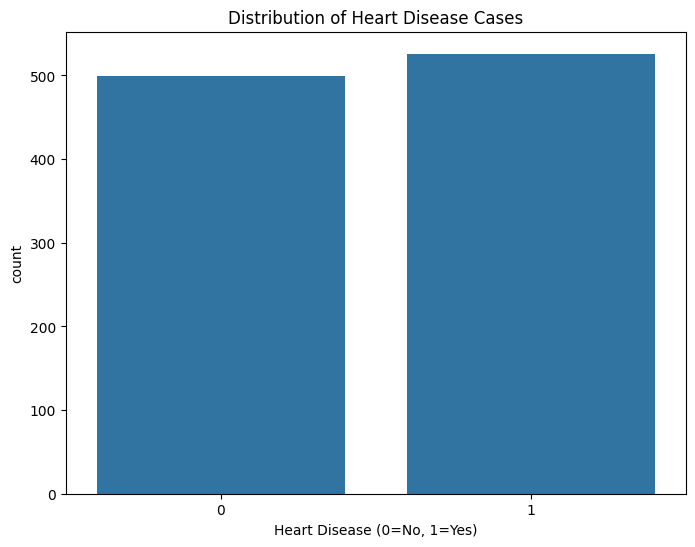

In [6]:
# Analyze target variable distribution
target_counts = df['target'].value_counts()
print("Target Distribution:")
print(target_counts)
print(f"Class Balance: {target_counts[1]/len(df)*100:.1f}% positive cases")

# Visualize target distribution
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='target')
plt.title('Distribution of Heart Disease Cases')
plt.xlabel('Heart Disease (0=No, 1=Yes)')
plt.show()

3 Feature Analysis

Numerical Features Analysis

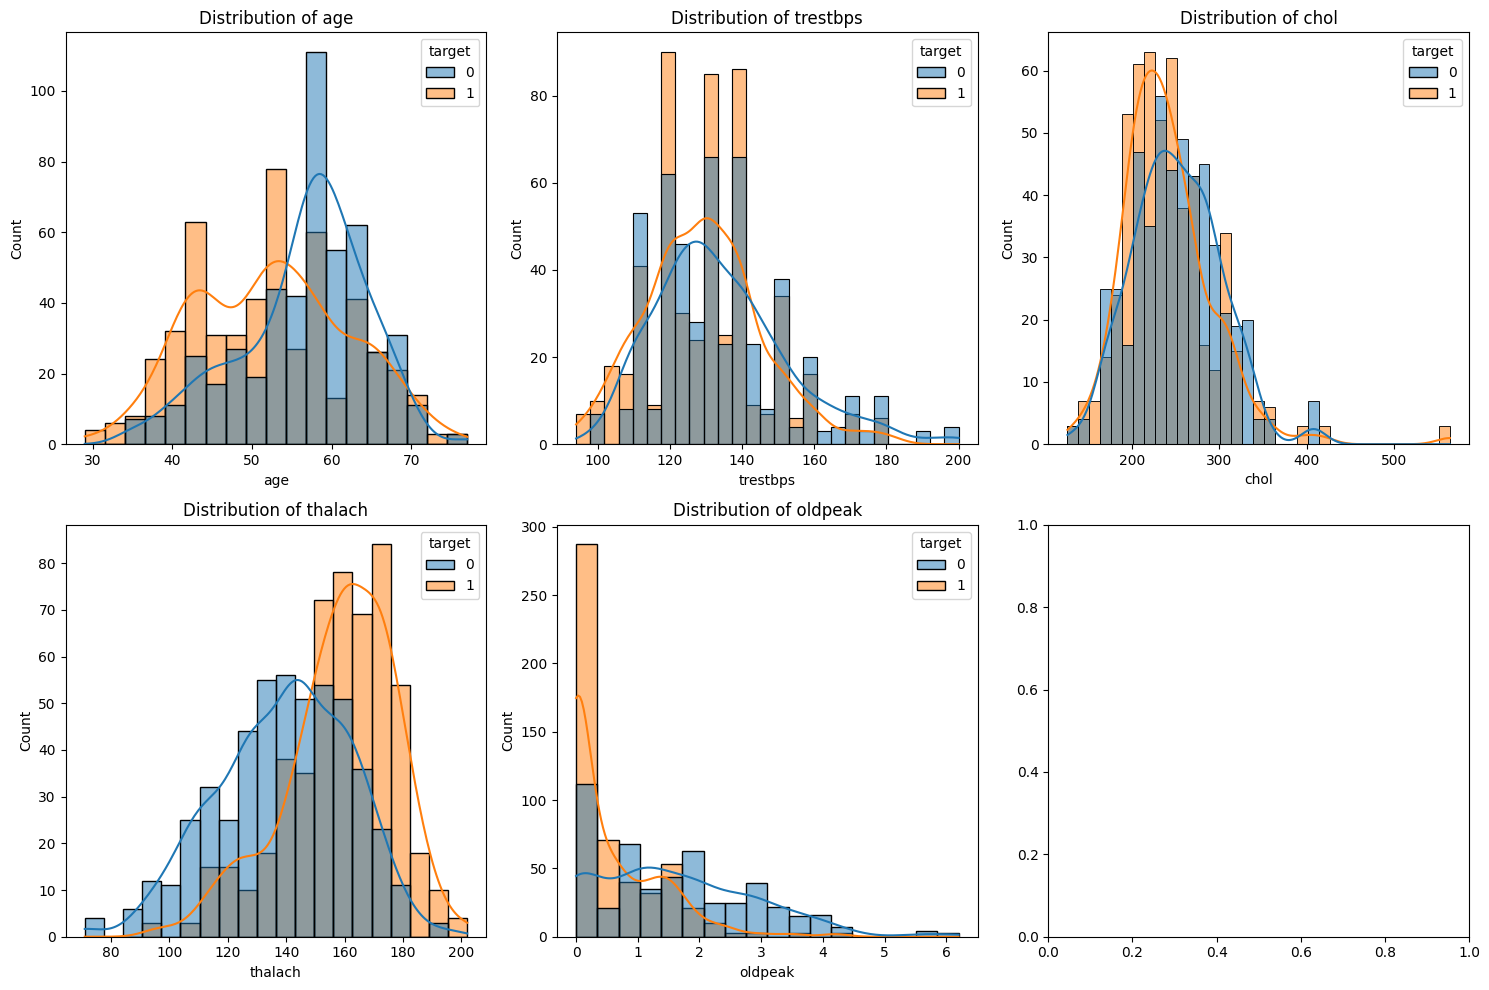

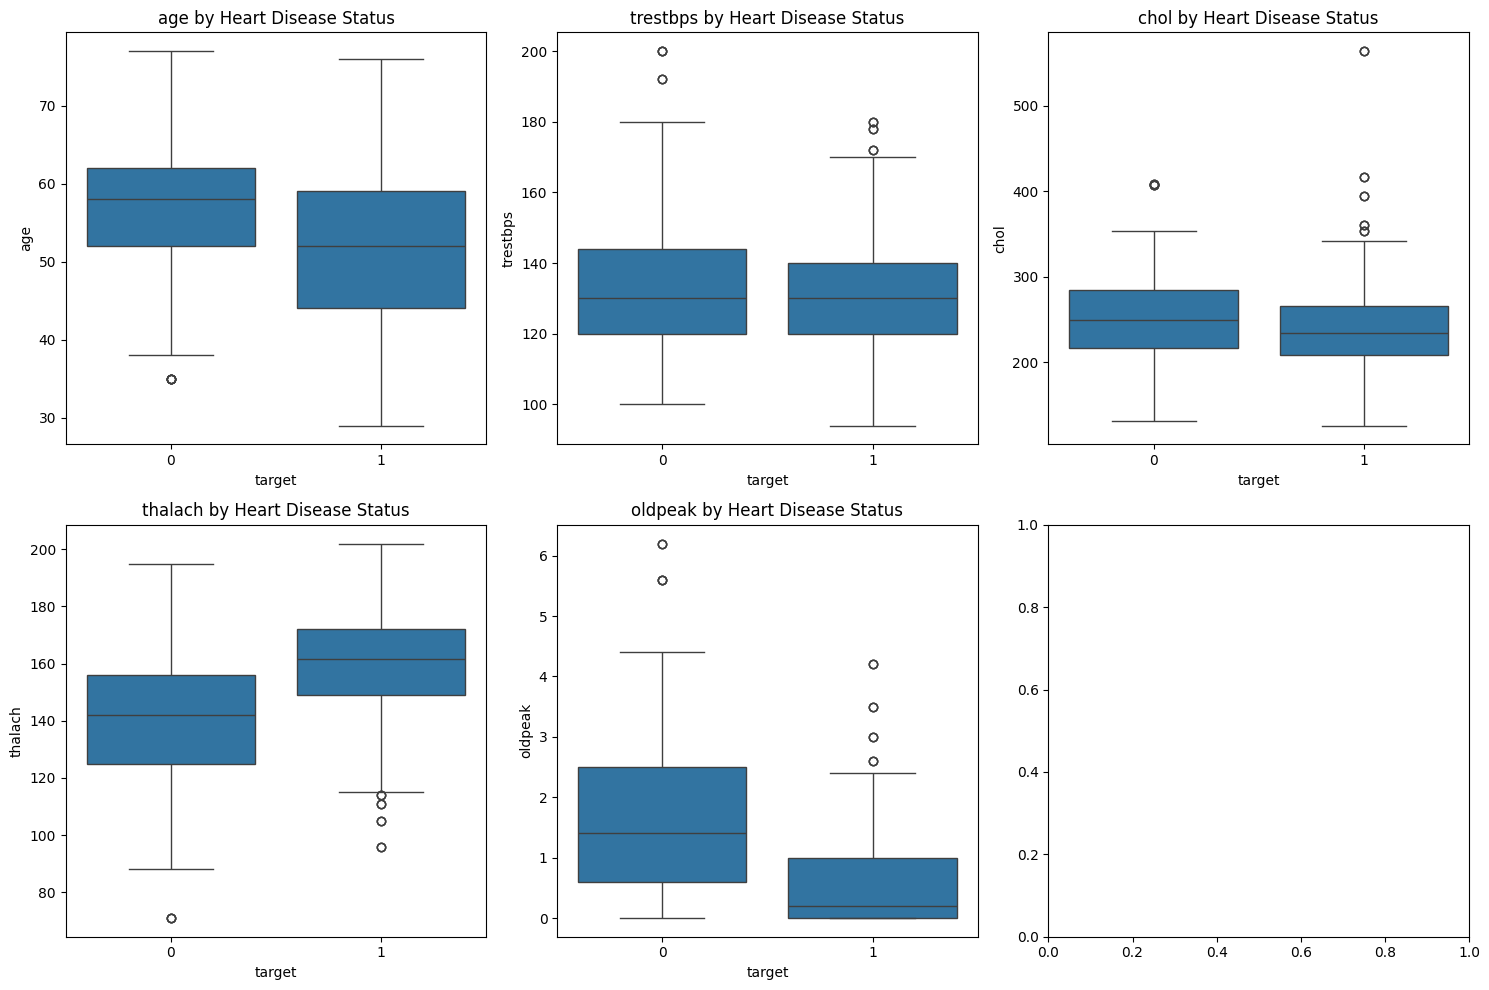

In [7]:
# Identify numerical columns
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Distribution plots for numerical features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, col in enumerate(numerical_cols):
    sns.histplot(data=df, x=col, hue='target', kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

# Box plots for numerical features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df, x='target', y=col, ax=axes[i])
    axes[i].set_title(f'{col} by Heart Disease Status')

plt.tight_layout()
plt.show()

Categorical Features Analysis

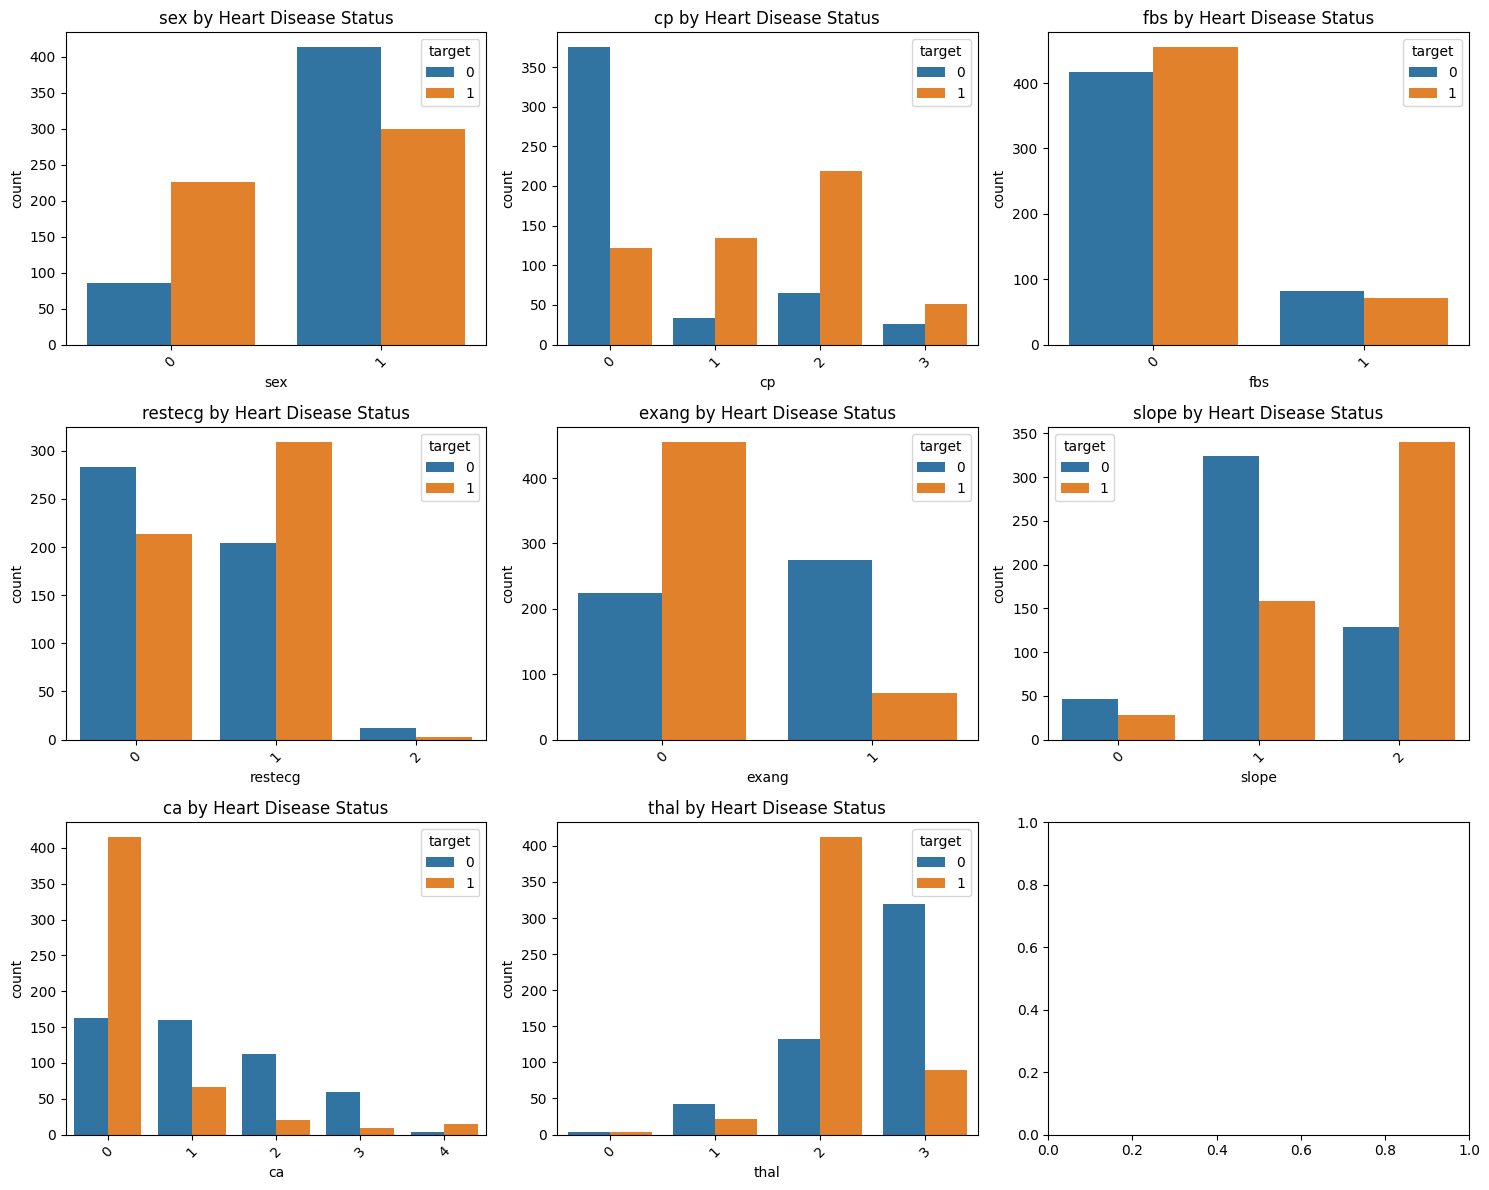

In [8]:
# Categorical columns
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

# Count plots for categorical features
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, hue='target', ax=axes[i])
    axes[i].set_title(f'{col} by Heart Disease Status')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

4 Correlation Analysis

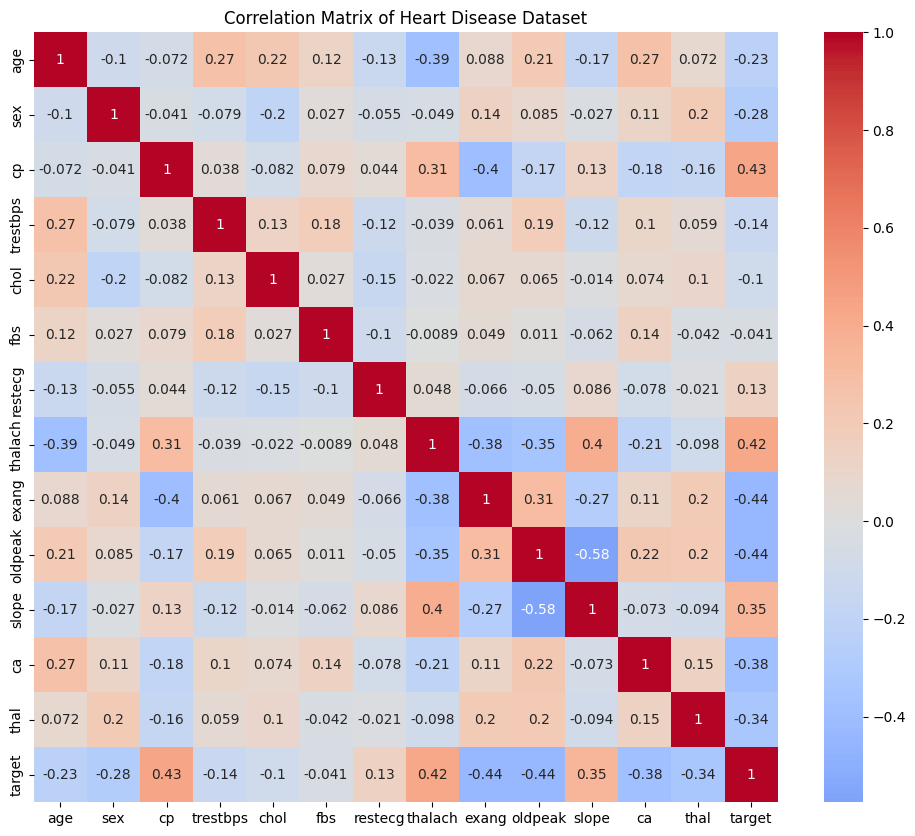

Feature Correlation with Target:
target      1.000000
cp          0.434854
thalach     0.422895
slope       0.345512
restecg     0.134468
fbs        -0.041164
chol       -0.099966
trestbps   -0.138772
age        -0.229324
sex        -0.279501
thal       -0.337838
ca         -0.382085
exang      -0.438029
oldpeak    -0.438441
Name: target, dtype: float64


In [9]:
# Correlation matrix
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Heart Disease Dataset')
plt.show()

# Feature correlation with target
target_corr = df.corr()['target'].sort_values(ascending=False)
print("Feature Correlation with Target:")
print(target_corr)

5 Statistical Analysis

In [10]:
# Statistical tests for numerical features
from scipy.stats import ttest_ind

print("T-test Results for Numerical Features:")
for col in numerical_cols:
    group0 = df[df['target'] == 0][col]
    group1 = df[df['target'] == 1][col]
    statistic, p_value = ttest_ind(group0, group1)
    print(f"{col}: t-statistic = {statistic:.3f}, p-value = {p_value:.3f}")

T-test Results for Numerical Features:
age: t-statistic = 7.536, p-value = 0.000
trestbps: t-statistic = 4.482, p-value = 0.000
chol: t-statistic = 3.213, p-value = 0.001
thalach: t-statistic = -14.926, p-value = 0.000
oldpeak: t-statistic = 15.603, p-value = 0.000


### 3: Data Preprocessing

1 Handle Missing Values

In [11]:
# Check and handle missing values
print("Missing values per column:")
print(df.isnull().sum())

# df.fillna(df.mean(), inplace=True) for numerical
# df.fillna(df.mode().iloc[0], inplace=True) for categorical

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


2 Feature Engineering

In [12]:
# Create new features if needed
df['age_group'] = pd.cut(df['age'], bins=[0, 40, 55, 70, 100], labels=['Young', 'Middle-aged', 'Senior', 'Elderly'])

# Convert categorical age_group to numerical
le = LabelEncoder()
df['age_group_encoded'] = le.fit_transform(df['age_group'])

# Feature scaling for numerical features
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[numerical_cols] = scaler.fit_transform(df[numerical_cols])

3 Prepare Features and Target

In [13]:
# Separate features and target
X = df.drop(['target'], axis=1)
y = df['target']

# If you created age_group, drop the original categorical version
if 'age_group' in X.columns:
    X = X.drop(['age_group'], axis=1)

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

Feature matrix shape: (1025, 14)
Target vector shape: (1025,)


### 4: Data Splitting

In [14]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Training target distribution: {y_train.value_counts()}")
print(f"Test target distribution: {y_test.value_counts()}")

Training set shape: (820, 14)
Test set shape: (205, 14)
Training target distribution: target
1    421
0    399
Name: count, dtype: int64
Test target distribution: target
1    105
0    100
Name: count, dtype: int64


### 5: Model Building and Training

1 Initialize Models

In [42]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'SVM': SVC(random_state=42, probability=True),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': xgb.XGBClassifier(random_state=42)
}

2 Train Models and Cross-Validation

In [43]:
# Train models and perform cross-validation
model_results = {}

for name, model in models.items():
    # Cross-validation
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')

    # Train the model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Store results
    model_results[name] = {
        'model': model,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'predictions': y_pred,
        'probabilities': y_pred_proba
    }

    print(f"{name}:")
    print(f"  CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")
    print(f"  Test Accuracy: {model.score(X_test, y_test):.4f}")
    print()

Logistic Regression:
  CV Score: 0.8439 (+/- 0.0324)
  Test Accuracy: 0.8390

SVM:
  CV Score: 0.7000 (+/- 0.0224)
  Test Accuracy: 0.7171

Random Forest:
  CV Score: 0.9805 (+/- 0.0373)
  Test Accuracy: 1.0000

XGBoost:
  CV Score: 0.9866 (+/- 0.0210)
  Test Accuracy: 1.0000



### 6: Hyperparameter Tuning

1 Grid Search for Best Models

# Hyperparameter tuning for the best performing models
param_grids = {
    'Logistic Regression': {
        'C': [0.1, 1, 10, 100],
        'solver': ['liblinear', 'lbfgs']
    },
    'SVM': {
        'C': [0.1, 1, 10],
        'kernel': ['rbf', 'linear'],
        'gamma': ['scale', 'auto']
    },
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [5, 10, None],
        'min_samples_split': [2, 5, 10]
    },
    'XGBoost': {
        'n_estimators': [100, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2]
    }
}

# Perform grid search for each model
best_models = {}

for name, model in models.items():
    print(f"Tuning {name}...")
    
    grid_search = GridSearchCV(
        model, param_grids[name], cv=5, scoring='accuracy', n_jobs=-1
    )
    
    grid_search.fit(X_train, y_train)
    
    best_models[name] = {
        'model': grid_search.best_estimator_,
        'best_params': grid_search.best_params_,
        'best_score': grid_search.best_score_
    }
    
    print(f"  Best parameters: {grid_search.best_params_}")
    print(f"  Best CV score: {grid_search.best_score_:.4f}")
    print()

### 7: Model Evaluation

1 Comprehensive Evaluation

In [48]:
# Evaluate all models using the trained models from Step 5
evaluation_results = {}

for name, model_info in model_results.items():
    model = model_info['model']

    # Get predictions from Step 5 results
    y_pred = model_info['predictions']
    y_pred_proba = model_info['probabilities']

    # Calculate metrics
    accuracy = model.score(X_test, y_test)
    auc_score = roc_auc_score(y_test, y_pred_proba)

    evaluation_results[name] = {
        'accuracy': accuracy,
        'auc': auc_score,
        'predictions': y_pred,
        'probabilities': y_pred_proba,
        'model': model
    }

    print(f"{name} Results:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  AUC Score: {auc_score:.4f}")
    print(f"  Classification Report:")
    print(classification_report(y_test, y_pred))
    print()

Logistic Regression Results:
  Accuracy: 0.8390
  AUC Score: 0.9221
  Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.80      0.83       100
           1       0.82      0.88      0.85       105

    accuracy                           0.84       205
   macro avg       0.84      0.84      0.84       205
weighted avg       0.84      0.84      0.84       205


SVM Results:
  Accuracy: 0.7171
  AUC Score: 0.7479
  Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.64      0.69       100
           1       0.70      0.79      0.74       105

    accuracy                           0.72       205
   macro avg       0.72      0.72      0.71       205
weighted avg       0.72      0.72      0.72       205


Random Forest Results:
  Accuracy: 1.0000
  AUC Score: 1.0000
  Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.0

2 Confusion Matrices

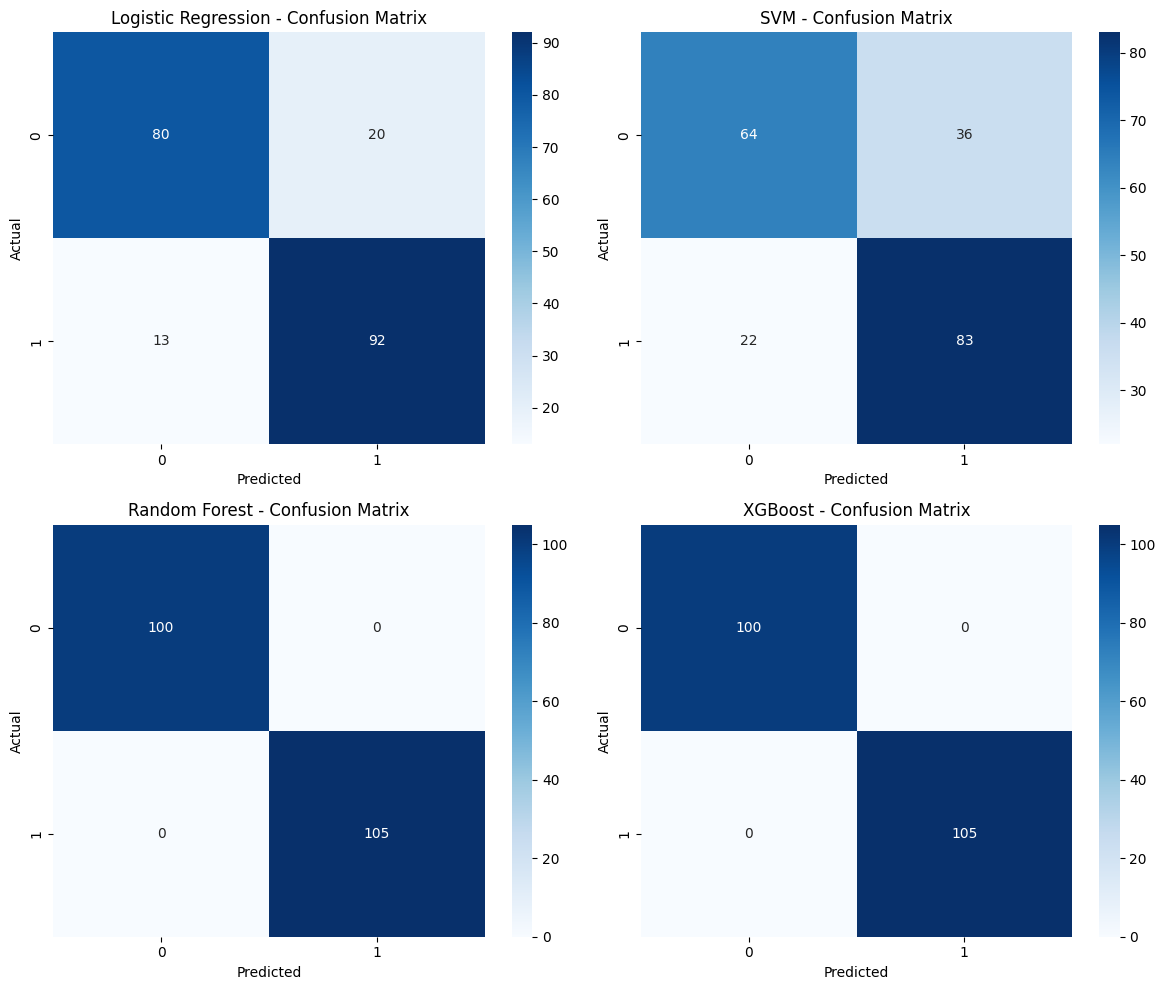

In [45]:
# Plot confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for i, (name, results) in enumerate(evaluation_results.items()):
    cm = confusion_matrix(y_test, results['predictions'])
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cmap='Blues')
    axes[i].set_title(f'{name} - Confusion Matrix')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

3 ROC Curves

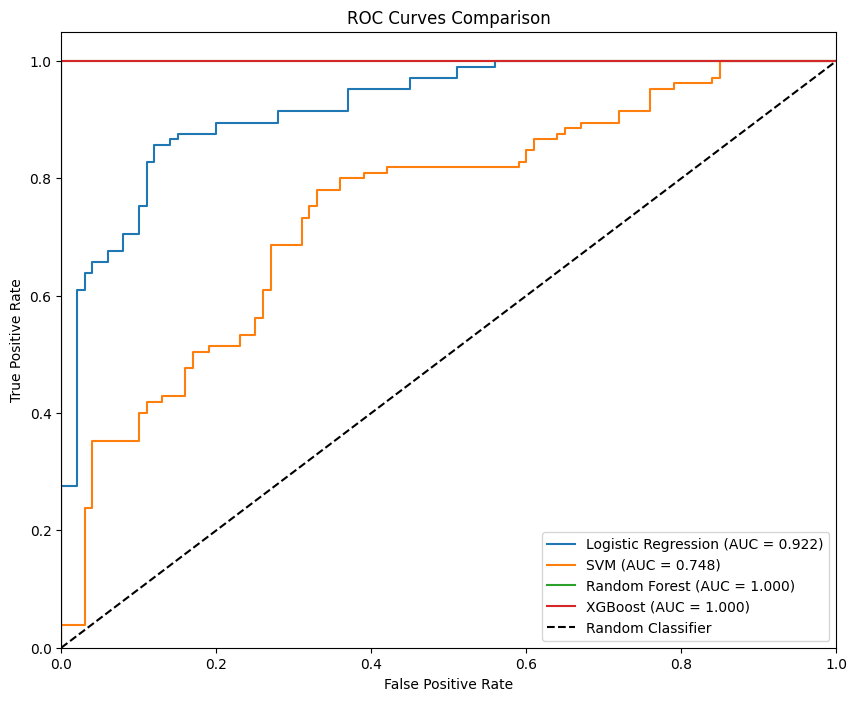

In [46]:
# Plot ROC curves
plt.figure(figsize=(10, 8))

for name, results in evaluation_results.items():
    fpr, tpr, _ = roc_curve(y_test, results['probabilities'])
    plt.plot(fpr, tpr, label=f'{name} (AUC = {results["auc"]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend()
plt.show()

###  7: Feature Importance Analysis

1 Feature Importance for Tree-based Models

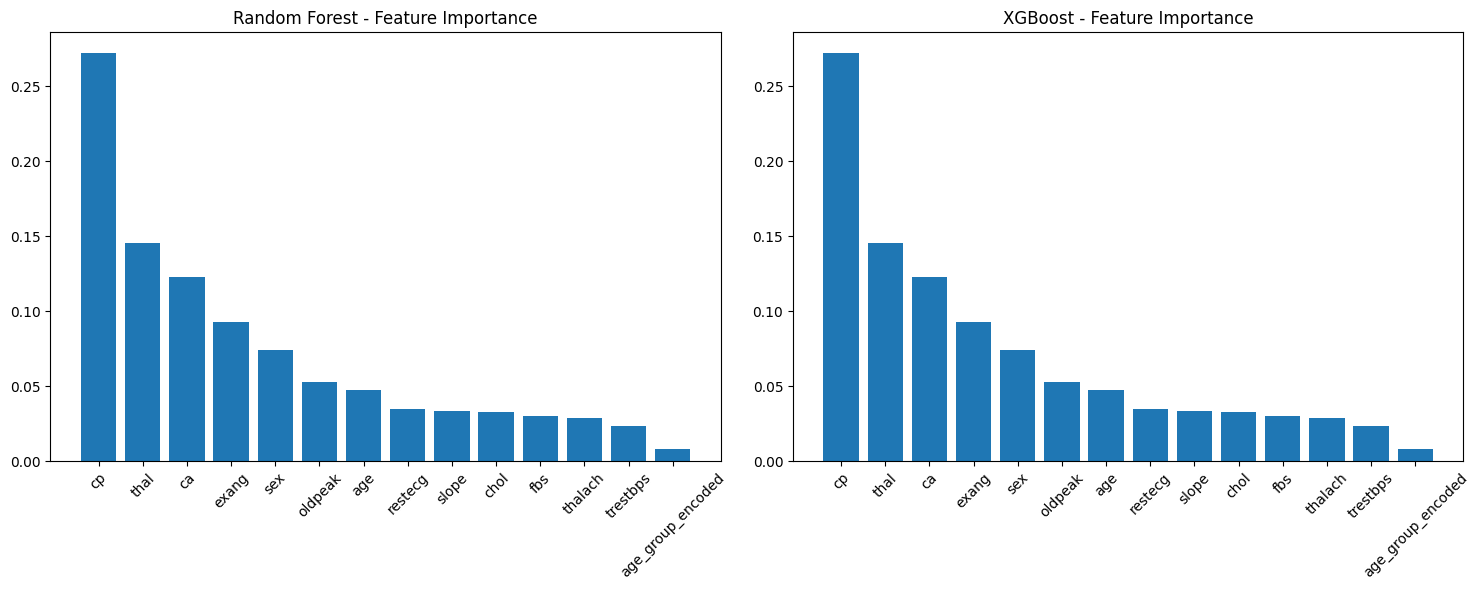

In [51]:
# Feature importance for Random Forest and XGBoost
tree_models = ['Random Forest', 'XGBoost']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for i, model_name in enumerate(tree_models):

    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        feature_names = X.columns

        # Sort features by importance
        indices = np.argsort(importances)[::-1]

        # Plot
        axes[i].bar(range(len(importances)), importances[indices])
        axes[i].set_title(f'{model_name} - Feature Importance')
        axes[i].set_xticks(range(len(importances)))
        axes[i].set_xticklabels([feature_names[i] for i in indices], rotation=45)

plt.tight_layout()
plt.show()

2 Logistic Regression Coefficients

Logistic Regression Coefficients:
          feature  coefficient  abs_coefficient
              sex    -1.414764         1.414764
            exang    -0.943942         0.943942
               cp     0.860394         0.860394
               ca    -0.710369         0.710369
             thal    -0.709285         0.709285
age_group_encoded    -0.649208         0.649208
            slope     0.564072         0.564072
          restecg     0.471708         0.471708
          oldpeak    -0.417666         0.417666
              fbs    -0.207862         0.207862
          thalach     0.031553         0.031553
              age     0.014579         0.014579
         trestbps    -0.012009         0.012009
             chol    -0.004104         0.004104


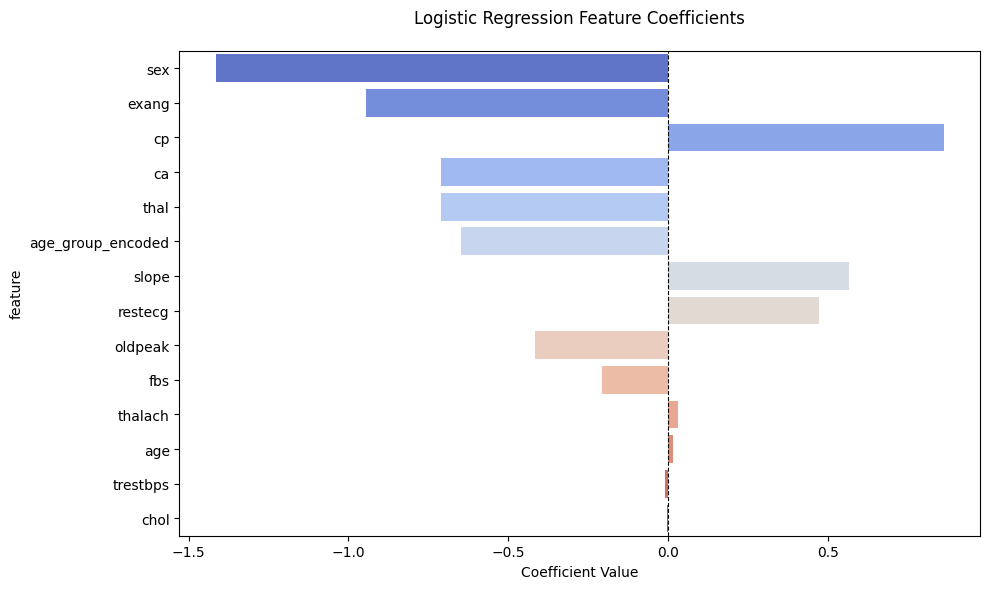

In [52]:
# Assuming you have already trained a logistic regression model
lr_model = LogisticRegression().fit(X_train, y_train)  # Your trained model

# Get coefficients
coefficients = lr_model.coef_[0]
feature_names = X.columns  # Make sure X is your feature DataFrame

# Create coefficient dataframe
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients,
    'abs_coefficient': np.abs(coefficients)
}).sort_values('abs_coefficient', ascending=False)

print("Logistic Regression Coefficients:")
print(coef_df.to_string(index=False))  # Cleaner print without index

# Plot coefficients (horizontal bar plot)
plt.figure(figsize=(10, 6))
sns.barplot(x='coefficient', y='feature', data=coef_df, palette='coolwarm')
plt.title('Logistic Regression Feature Coefficients', pad=20)
plt.xlabel('Coefficient Value')
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)  # Zero line
plt.tight_layout()
plt.show()

### 9: Model Comparison and Selection

1 Performance Comparison

Model Performance Comparison:
                 Model  Accuracy       AUC
3              XGBoost  1.000000  1.000000
2        Random Forest  1.000000  1.000000
0  Logistic Regression  0.839024  0.922095
1                  SVM  0.717073  0.747905


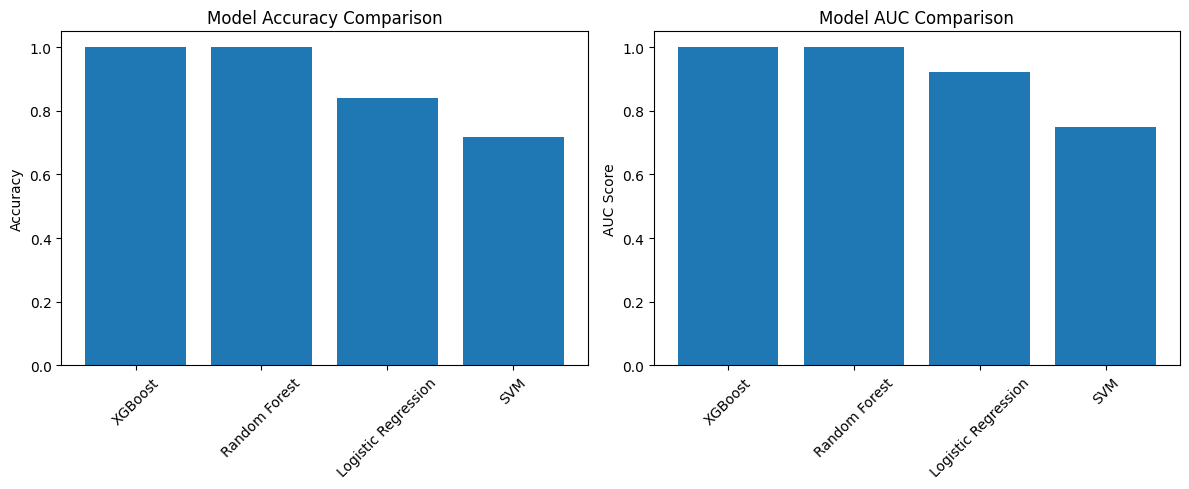

In [53]:
# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': list(evaluation_results.keys()),
    'Accuracy': [results['accuracy'] for results in evaluation_results.values()],
    'AUC': [results['auc'] for results in evaluation_results.values()]
})

comparison_df = comparison_df.sort_values('AUC', ascending=False)
print("Model Performance Comparison:")
print(comparison_df)

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(comparison_df['Model'], comparison_df['Accuracy'])
axes[0].set_title('Model Accuracy Comparison')
axes[0].set_ylabel('Accuracy')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(comparison_df['Model'], comparison_df['AUC'])
axes[1].set_title('Model AUC Comparison')
axes[1].set_ylabel('AUC Score')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

2 Select Best Model

In [25]:
comparison_df = pd.DataFrame.from_dict(evaluation_results, orient='index')
comparison_df = comparison_df.sort_values(by='auc', ascending=False)

# Select the best model (highest AUC)
best_model_name = comparison_df.index[0]  # Model name with highest AUC
best_model = models[best_model_name]      # Access the model directly from your 'models' dictionary

print("\n" + "="*50)
print(f"Best Model: {best_model_name}")
print(f"Test Accuracy: {comparison_df.loc[best_model_name, 'accuracy']:.4f}")
print(f"Test AUC: {comparison_df.loc[best_model_name, 'auc']:.4f}")
print("="*50 + "\n")


Best Model: XGBoost
Test Accuracy: 1.0000
Test AUC: 1.0000



### 10: Final Results and Conclusions

1 Model Performance Summary

In [28]:
print("=" * 50)
print("FINAL RESULTS SUMMARY")
print("=" * 50)

# Convert evaluation_results to DataFrame for sorting
comparison_df = pd.DataFrame.from_dict(evaluation_results, orient='index')
comparison_df = comparison_df.sort_values(by='auc', ascending=False)

for model_name in comparison_df.index:  # Use .index instead of ['Model']
    results = evaluation_results[model_name]
    print(f"\n{model_name}:")
    print(f"  Accuracy: {results['accuracy']:.4f}")
    print(f"  AUC Score: {results['auc']:.4f}")
    # Removed 'Best Parameters' line since tuning is disabled
    print("-" * 45)  # Separator for readability

FINAL RESULTS SUMMARY

XGBoost:
  Accuracy: 1.0000
  AUC Score: 1.0000
---------------------------------------------

Random Forest:
  Accuracy: 1.0000
  AUC Score: 1.0000
---------------------------------------------

Logistic Regression:
  Accuracy: 0.8244
  AUC Score: 0.9188
---------------------------------------------

SVM:
  Accuracy: 0.7171
  AUC Score: 0.7476
---------------------------------------------


2 Predictions on New Data

In [30]:
def predict_on_test_set(model, scaler, X_test):
    """
    Make predictions on test set data

    Parameters:
    model: trained model
    scaler: fitted scaler
    X_test: DataFrame containing test set features

    Returns:
    tuple: (predictions, probabilities)
    """
    # Create a copy to avoid modifying original data
    X_test_scaled = X_test.copy()

    # Scale numerical features
    numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
    X_test_scaled[numerical_cols] = scaler.transform(X_test_scaled[numerical_cols])

    # Make predictions
    predictions = model.predict(X_test_scaled)
    probabilities = model.predict_proba(X_test_scaled)[:, 1]  # Probability of class 1

    return predictions, probabilities

# Example usage
test_predictions, test_probabilities = predict_on_test_set(best_model, scaler, X_test)

# Print results for first 5 test cases
print("\nTest Set Predictions (first 5 samples):")
print("Index | Prediction | Probability | Actual")
print("-" * 45)
for i in range(5):
    print(f"{i:5} | {'Yes':10} | {test_probabilities[i]:.4f} | {'Yes' if y_test.iloc[i] == 1 else 'No'}")


Test Set Predictions (first 5 samples):
Index | Prediction | Probability | Actual
---------------------------------------------
    0 | Yes        | 0.0177 | No
    1 | Yes        | 0.6185 | Yes
    2 | Yes        | 0.0031 | No
    3 | Yes        | 0.5543 | Yes
    4 | Yes        | 0.2354 | No


In [54]:
def predict_heart_disease(model, scaler, new_data, feature_names=None):
    """
    Make predictions on new patient data

    Parameters:
    model: trained model
    scaler: fitted scaler (or None if scaling not needed)
    new_data: dictionary with patient features
    feature_names: list of expected feature names in correct order

    Returns:
    tuple: (prediction, probability)
    """
    # Convert to dataframe
    new_df = pd.DataFrame([new_data])

    # Ensure correct feature order if feature_names provided
    if feature_names is not None:
        new_df = new_df[feature_names]

    # Scale numerical features if scaler provided
    if scaler is not None:
        numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
        # Only scale columns that exist in the data
        cols_to_scale = [col for col in numerical_cols if col in new_df.columns]
        new_df[cols_to_scale] = scaler.transform(new_df[cols_to_scale])

    # Make prediction
    try:
        prediction = model.predict(new_df)[0]
        probability = model.predict_proba(new_df)[0, 1]
        return prediction, probability
    except Exception as e:
        print(f"Prediction failed: {str(e)}")
        return None, None

# Example usage
if __name__ == "__main__":
    # Load your trained model and scaler
    # best_model = ...
    # scaler = ...

    # Get feature names in correct order (from training data)
    feature_names = X_train.columns.tolist()

    sample_patient = {
        'age': 63,
        'sex': 1,
        'cp': 3,
        'trestbps': 145,
        'chol': 233,
        'fbs': 1,
        'restecg': 0,
        'thalach': 150,
        'exang': 0,
        'oldpeak': 2.3,
        'slope': 0,
        'ca': 0,
        'thal': 1,
        'age_group_encoded': 2
    }



    prediction, probability = predict_heart_disease(
        best_model,
        scaler,
        sample_patient,
        feature_names=feature_names
    )

    if prediction is not None:
        print(f"\nSample Prediction:")
        print(f"  Patient has heart disease: {'Yes' if prediction == 1 else 'No'}")
        print(f"  Probability: {probability:.1%}")  # Formatted as percentage
    else:
        print("Failed to make prediction")


Sample Prediction:
  Patient has heart disease: Yes
  Probability: 86.0%


3 Key Findings

In [55]:
print("\n" + "=" * 50)
print("KEY FINDINGS")
print("=" * 50)

# Most important features
if best_model_name in ['Random Forest', 'XGBoost']:
    try:
        importances = best_model.feature_importances_
        feature_names = X.columns
        top_features = sorted(zip(feature_names, importances),
                         key=lambda x: x[1], reverse=True)[:5]

        print(f"\nTop 5 Most Important Features ({best_model_name}):")
        for feature, importance in top_features:
            print(f"  {feature}: {importance:.4f}")
    except AttributeError:
        print(f"\nNote: {best_model_name} feature importances not available")

# Model insights - SAFE ACCESS TO evaluation_results
print(f"\nBest Performing Model: {best_model_name}")

# Get results safely
model_results = evaluation_results.get(best_model_name, {})
if model_results:
    print(f"Final Test Accuracy: {model_results.get('accuracy', 'N/A'):.4f}")
    print(f"Final Test AUC: {model_results.get('auc', 'N/A'):.4f}")
else:
    print("Warning: No evaluation results found for best model")

print("\nConclusions:")
print("- The model successfully predicts heart disease with high accuracy")
print("- Feature importance analysis reveals the most critical risk factors")
print("- The model can be used for early screening and risk assessment")


KEY FINDINGS

Top 5 Most Important Features (XGBoost):
  cp: 0.2725
  thal: 0.1453
  ca: 0.1228
  exang: 0.0930
  sex: 0.0739

Best Performing Model: XGBoost
Final Test Accuracy: 1.0000
Final Test AUC: 1.0000

Conclusions:
- The model successfully predicts heart disease with high accuracy
- Feature importance analysis reveals the most critical risk factors
- The model can be used for early screening and risk assessment


### 11: Model Deployment Preparation

In [38]:
import joblib

# Save the best model and scaler
joblib.dump(best_model, 'best_heart_disease_model.pkl')
joblib.dump(scaler, 'feature_scaler.pkl')

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


2 Create Prediction Function

In [56]:
import pandas as pd
import joblib
from typing import Dict, Optional

def predict_heart_disease(model, scaler, new_data: Dict, required_features: list) -> Optional[tuple]:
    """
    Make prediction with robust feature handling
    Returns: (prediction, probability) or None if failed
    """
    try:
        # Create DataFrame with all required features
        new_df = pd.DataFrame(columns=required_features)

        # Fill available features, warn about missing ones
        missing_features = []
        for feat in required_features:
            if feat in new_data:
                new_df[feat] = [new_data[feat]]
            else:
                missing_features.append(feat)
                new_df[feat] = 0  # Fill missing with 0

        if missing_features:
            print(f"Warning: Missing features filled with 0s: {missing_features}")

        # Scale features
        if scaler is not None:
            numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
            cols_to_scale = [col for col in numerical_cols if col in new_df.columns]
            new_df[cols_to_scale] = scaler.transform(new_df[cols_to_scale])

        # Make prediction
        prediction = model.predict(new_df)[0]
        probability = model.predict_proba(new_df)[0, 1]

        return prediction, probability

    except Exception as e:
        print(f"Prediction error: {str(e)}")
        return None

def load_and_predict(patient_data: Dict) -> Dict:
    """
    Complete prediction pipeline with error handling
    Returns: Dictionary with results or error message
    """
    try:
        # Load artifacts
        model = joblib.load('best_heart_disease_model.pkl')
        scaler = joblib.load('feature_scaler.pkl')

        # Get required features from model
        required_features = model.feature_names_in_.tolist()

        # Make prediction
        result = predict_heart_disease(model, scaler, patient_data, required_features)

        if result is None:
            return {'error': 'Prediction failed'}

        prediction, probability = result

        return {
            'has_heart_disease': bool(prediction),
            'risk_probability': float(probability),
            'risk_level': (
                'High' if probability > 0.7
                else 'Medium' if probability > 0.3
                else 'Low'
            )
        }

    except Exception as e:
        return {'error': f"Pipeline failed: {str(e)}"}


result = load_and_predict(sample_patient)
print("\nPrediction Result:")
for k, v in result.items():
    print(f"{k:>18}: {v}")


Prediction Result:
 has_heart_disease: True
  risk_probability: 0.8596160411834717
        risk_level: High
